<a href="https://colab.research.google.com/github/chadiboudaher/ml-dl-pytorch/blob/main/mnist_lenet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/chadiboudaher/ml-dl-pytorch

Cloning into 'ml-dl-pytorch'...
remote: Enumerating objects: 298, done.
remote: Counting objects: 100% (298/298), done.
remote: Compressing objects: 100% (219/219), done.
remote: Total 298 (delta 103), reused 244 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (298/298), 2.13 MiB | 15.18 MiB/s, done.
Resolving deltas: 100% (103/103), done.


In [ ]:
!cd ml-dl-pytorch/

In [ ]:
!cd ml-dl-pytorch/notebooks/

In [ ]:
!pwd

/content


In [ ]:
%cd ml-dl-pytorch/notebooks/

/content/ml-dl-pytorch/notebooks


In [ ]:
!pwd

/content/ml-dl-pytorch/notebooks


# Implementing LeNet-5 in PyTorch

In [ ]:
import numpy as np
from datetime import datetime

import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
RANDOM_SEED = 42
BATCH_SIZE = 32 # Randomly chosen, 32 is mostly used for batching
IMG_SIZE = 32
N_CLASSES = 10 # 1 through 10

# 1. Get data from torchvision `Datasets`

In [11]:
# Define transforms - can be used for both train and test data
transforms = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# Get training data
train_data = datasets.MNIST(root="data",
                            train=True,
                            transform=transforms,
                            download=True)

# Get Testing data
test_data = datasets.MNIST(root="data",
                           train=False,
                           transform=transforms)

# Define train DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

# Define test DataLoader
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 66.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.80MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


In [33]:
print(f"Train data shape: {train_data.data.shape}")
print(f"Test data shape: {test_data.data.shape}")

img, label = next(iter(train_dataloader))
# 32 batches each with shapes [color_channels, height, width]
print(f"Train dataloader shape: {img.shape}")
print(f"train dataloader label: {label.shape}")

Train data shape: torch.Size([60000, 28, 28])
Test data shape: torch.Size([10000, 28, 28])
Train dataloader shape: torch.Size([32, 1, 32, 32])
train dataloader label: torch.Size([32])


## 1.1 Plotting data sample

Text(0.5, 0.98, 'MNIST DATASET')

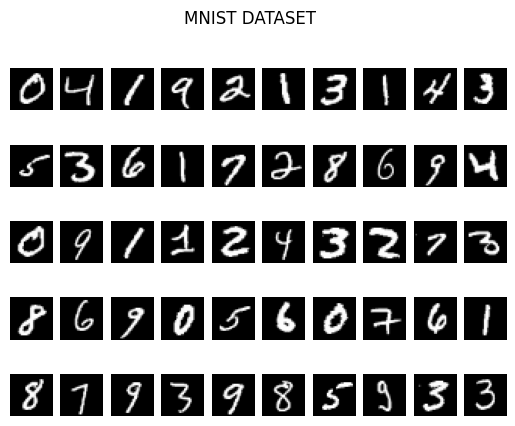

In [34]:
N_COLS = 10
N_ROWS = 5

fig = plt.figure()
for index in range(1, N_COLS * N_ROWS + 1):
  plt.subplot(N_ROWS, N_COLS, index)
  plt.axis(False)
  plt.imshow(train_data.data[index], cmap="grey")
plt.suptitle("MNIST DATASET")

## Architecture of LeNet-5
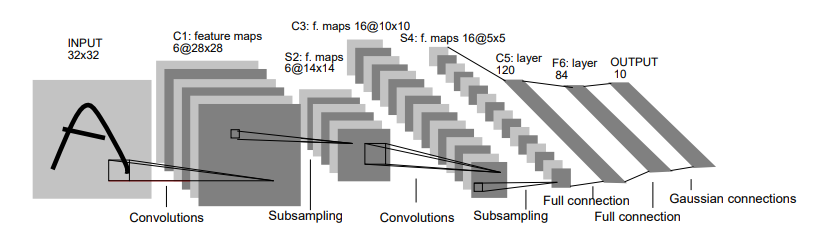

In [35]:
class LeNet5(nn.Module):
  def __init__(self, n_classes):
    super().__init__()
    # 32 -> average pool = 2 & stride = 1 -> 16
    self.feature_extractor = nn.Sequential(
        nn.Conv2d(in_channels=1,
                  out_channels=6,
                  kernel_size=5,
                  stride=1),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2),
        nn.Conv2d(in_channels=6,
                  out_channels=16,
                  kernel_size=5,
                  stride=1),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2),
        nn.Conv2d(in_channels=16,
                  out_channels=120,
                  kernel_size=5,
                  stride=1),
        nn.Tanh()
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=120, out_features=84),
        nn.Tanh(),
        nn.Linear(in_features=84, out_features=n_classes)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.feature_extractor(x)
    x = self.classifier(x)
    return x

In [41]:
model = LeNet5(N_CLASSES).to(DEVICE)

# Setup optimizer
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)
# Setup loss function
loss_fn = nn.CrossEntropyLoss()

In [42]:
def accuracy_fn(model: nn.Module, data_loader, device):
  '''
  Function for computing the accuracy of the predictions over
  the entire data_loader
  '''

  correct_pred = 0
  n = 0

  with torch.inference_mode():
    model.eval()

    for X, y_true in data_loader:
      X = X.to(device)
      y_true = y_true.to(device)

      logits = model(X)
      y_pred = torch.argmax(logits, dim=1)

      correct_pred += (y_pred == y_true).sum().item()
      n += y_true.size(0)

  accuracy = correct_pred / n
  return accuracy

In [43]:
from tqdm.auto import tqdm

N_EPOCHS = 6

for epoch in tqdm(range(N_EPOCHS)):

  train_loss, train_acc = 0, 0
  model.train()

  for X, y in train_dataloader:

    X = X.to(DEVICE)
    y = y.to(DEVICE)

    logits = model(X)
    loss = loss_fn(logits, y)

    y_pred = logits.argmax(dim=1)
    accuracy = (y_pred == y).float().mean().item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    train_acc += accuracy

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      X_test = X_test.to(DEVICE)
      y_test = y_test.to(DEVICE)

      test_logits = model(X_test)
      loss = loss_fn(test_logits, y_test)

      y_pred = test_logits.argmax(dim=1)
      accuracy = (y_pred == y_test).float().mean().item()

      test_loss += loss.item()
      test_acc += accuracy

  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)

  print(
    f"Epoch {epoch+1}/{N_EPOCHS} | "
    f"Train Loss: {train_loss:.4f} | "
    f"Train Acc: {train_acc:.4f} | "
    f"Test Loss: {test_loss:.4f} | "
    f"Test Acc: {test_acc:.4f}"
  )


  0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1/6 | Train Loss: 0.2323 | Train Acc: 0.9318 | Test Loss: 0.0935 | Test Acc: 0.9712
Epoch 2/6 | Train Loss: 0.0796 | Train Acc: 0.9756 | Test Loss: 0.0654 | Test Acc: 0.9803
Epoch 3/6 | Train Loss: 0.0557 | Train Acc: 0.9831 | Test Loss: 0.0518 | Test Acc: 0.9843
Epoch 4/6 | Train Loss: 0.0432 | Train Acc: 0.9868 | Test Loss: 0.0562 | Test Acc: 0.9831
Epoch 5/6 | Train Loss: 0.0375 | Train Acc: 0.9879 | Test Loss: 0.0493 | Test Acc: 0.9842
Epoch 6/6 | Train Loss: 0.0296 | Train Acc: 0.9908 | Test Loss: 0.0421 | Test Acc: 0.9855
